In [1]:
import nltk
from nltk.corpus import treebank
import statistics
import matplotlib.pyplot as plt
import numpy as np
import re

# Download and load corpus
nltk.download('treebank')
sentences = treebank.sents()
words = treebank.words()
tagged_words = treebank.tagged_words()

# Remove trace tokens and empty categories
TRACE_TOKEN_PATTERN = re.compile(r'^\*.*\*$|^\*$|^\*-?\d+$|^0$')
def is_valid_token(word, pos_tag=None):
    if pos_tag == '-NONE-':
        return False
    if TRACE_TOKEN_PATTERN.match(word):
        return False
    return True

# Cleaned sentences as strings
cleaned_sentences = []
for sentence in treebank.tagged_sents():
    cleaned_tokens = [word for word, pos in sentence if is_valid_token(word, pos)]
    if cleaned_tokens:
        cleaned_sentences.append(" ".join(cleaned_tokens))

# --- Remove outliers based on sentence length ---
sentence_lengths = [len(sentence.split()) for sentence in cleaned_sentences]
Q1 = np.percentile(sentence_lengths, 25)
Q3 = np.percentile(sentence_lengths, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

filtered_cleaned_sentences = [
    sentence for sentence in cleaned_sentences
    if lower_bound <= len(sentence.split()) <= upper_bound
]

# Gather statistics on the filtered cleaned data
filtered_total_sentences = len(filtered_cleaned_sentences)
filtered_all_tokens = [token for sentence in filtered_cleaned_sentences for token in sentence.split()]
filtered_total_tokens = len(filtered_all_tokens)
filtered_unique_tokens = set(filtered_all_tokens)
filtered_total_unique_tokens = len(filtered_unique_tokens)

# Sentence length statistics
filtered_sentence_lengths = [len(sentence.split()) for sentence in filtered_cleaned_sentences]
if len(filtered_sentence_lengths) > 1:
    filtered_variance_sentence_length = round(statistics.pvariance(filtered_sentence_lengths), 3)
    filtered_std_dev_sentence_length = round(statistics.stdev(filtered_sentence_lengths), 3)
else:
    filtered_variance_sentence_length = 0
    filtered_std_dev_sentence_length = 0

# Average sentence length
filtered_average_sentence_length = round(filtered_total_tokens / filtered_total_sentences if filtered_total_sentences else 0, 3)

print(f"Original sentences: {len(cleaned_sentences)}")
print("\n--- Statistics for Filtered Cleaned Data ---")
print("Total number of sentences:", filtered_total_sentences)
print("Total number of words:", filtered_total_tokens)
print("Total number of unique words:", filtered_total_unique_tokens)
print("Average sentence length:", filtered_average_sentence_length)
print("Variance of sentence lengths:", filtered_variance_sentence_length)
print("Standard deviation of sentence lengths:", filtered_std_dev_sentence_length)

[nltk_data] Downloading package treebank to
[nltk_data]     /Users/larsheijnen/nltk_data...
[nltk_data]   Package treebank is already up-to-date!


Original sentences: 3914

--- Statistics for Filtered Cleaned Data ---
Total number of sentences: 3868
Total number of words: 90895
Total number of unique words: 11647
Average sentence length: 23.499
Variance of sentence lengths: 106.825
Standard deviation of sentence lengths: 10.337


In [2]:
from transformers import BertTokenizer, BertModel
import torch
import numpy as np

# Load BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

def get_bert_embeddings_no_padding(texts):
    # Determine optimal device for Apple Silicon
    device = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
    
    # Set model to device and evaluation mode only once
    model.to(device)
    model.eval()
    
    # Preallocate output array for better memory efficiency
    embeddings = np.zeros((len(texts), model.config.hidden_size), dtype=np.float32)
    
    with torch.no_grad():  # Disable gradient calculation for inference
        # Process texts in small batches for better memory management
        batch_size = 32
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]
            batch_embeddings = []
            
            # Process each text individually to match original behavior
            for j, text in enumerate(batch_texts):
                # Keep padding=False to match original exactly
                inputs = tokenizer(text, padding=False, truncation=True, return_tensors='pt').to(device)
                outputs = model(**inputs)
                emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
                batch_embeddings.append(emb[0])
                
                # Free memory for individual processing
                del inputs, outputs
            
            # Update embeddings array
            embeddings[i:i+len(batch_texts)] = np.array(batch_embeddings)
            
            # Free memory explicitly after batch
            del batch_embeddings
            if device == 'mps' or device == 'cuda':
                torch.mps.empty_cache() if device == 'mps' else torch.cuda.empty_cache()
                
    return embeddings


print("Generating BERT embeddings for filtered_cleaned_sentences (preprocessed, outliers removed)...")
X_sentence_features = get_bert_embeddings_no_padding(filtered_cleaned_sentences)
print(f"Sentence BERT embeddings shape: {X_sentence_features.shape}")

get_bert_embeddings_no_padding([filtered_cleaned_sentences[0]])

Generating BERT embeddings for filtered_cleaned_sentences (preprocessed, outliers removed)...
Sentence BERT embeddings shape: (3868, 768)


array([[-4.86198276e-01,  2.93048412e-01,  3.75086993e-01,
        -3.84702384e-01, -1.77396685e-01, -5.29885292e-01,
         2.53705710e-01,  1.26502588e-01,  2.33976215e-01,
        -3.91963989e-01, -5.74748039e-01,  2.37874240e-02,
        -4.53744009e-02,  3.44385266e-01,  1.59705445e-01,
        -6.53184354e-02, -2.21710816e-01,  5.44918716e-01,
         2.04050243e-01, -3.10351998e-01, -2.53553241e-01,
        -6.99147046e-01,  6.85002208e-01,  8.21404979e-02,
        -1.12280577e-01, -2.87439346e-01, -1.02868676e-01,
        -3.81908268e-01, -4.05884564e-01, -5.37281573e-01,
         5.60068004e-02,  3.03228259e-01, -4.29823369e-01,
        -1.67788029e-01,  5.25796890e-01,  2.30641589e-01,
         5.94016373e-01, -3.33054066e-02,  2.52491176e-01,
         4.57178175e-01, -5.46683632e-02,  2.79393673e-01,
         5.22458196e-01, -4.93322819e-01, -1.40231624e-01,
        -5.15283465e-01, -2.63092327e+00, -1.74056724e-01,
        -1.22571692e-01, -1.94148242e-01,  1.66194677e-0

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    explained_variance_score,
    max_error,
    median_absolute_error
)
import numpy as np

# Target: sentence lengths
y = [len(sentence.split()) for sentence in filtered_cleaned_sentences]

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_sentence_features, y, test_size=0.2, random_state=42
)

# Train Linear Regression model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict on test set
y_pred = lr.predict(X_test)

# Evaluate the model with multiple metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
medae = median_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
explained_var = explained_variance_score(y_test, y_pred)
max_err = max_error(y_test, y_pred)

print(f"Test MSE: {mse:.3f}")
print(f"Test RMSE: {rmse:.3f}")
print(f"Test MAE: {mae:.3f}")
print(f"Test Median AE: {medae:.3f}")
print(f"Test Max Error: {max_err:.3f}")
print(f"Test R^2: {r2:.3f}")
print(f"Test Explained Variance: {explained_var:.3f}")

Test MSE: 18.289
Test RMSE: 4.277
Test MAE: 3.302
Test Median AE: 2.635
Test Max Error: 17.890
Test R^2: 0.837
Test Explained Variance: 0.838


Performing hierarchical clustering...
Clustering complete.


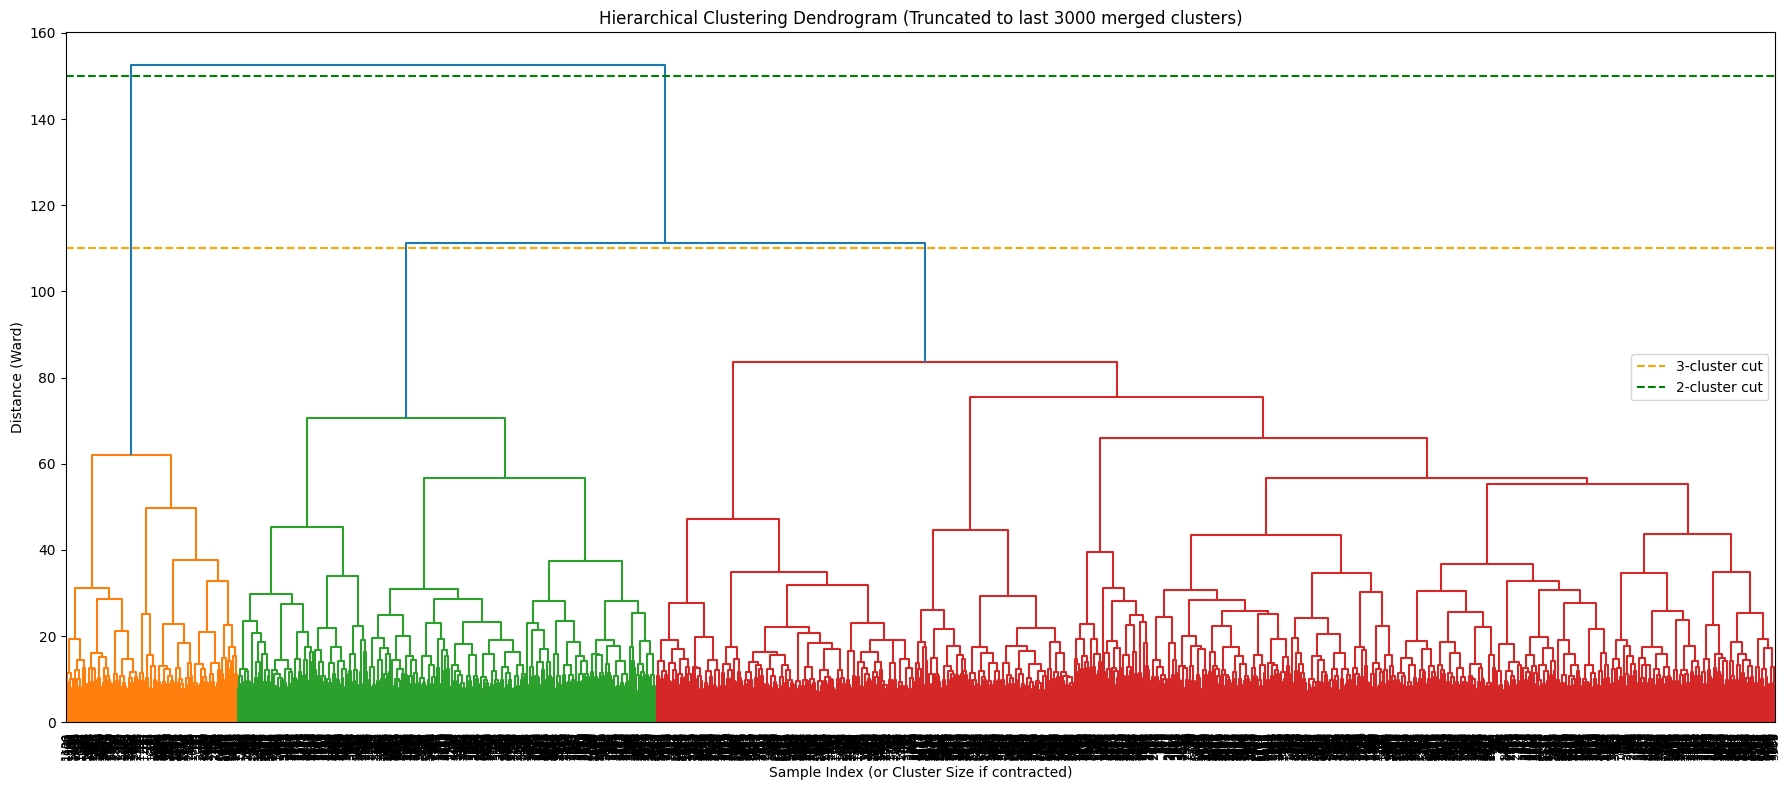

Dendrogram displayed, showing the structure of the last 3000 merged clusters.


In [7]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
import numpy as np


print("Performing hierarchical clustering...")
linked = linkage(X_sentence_features, method='ward')
print("Clustering complete.")


# showing only the last 'p' merged clusters.
p_clusters_to_show = 3000 # can be adjusted

plt.figure(figsize=(18, 8))
plt.title(f'Hierarchical Clustering Dendrogram (Truncated to last {p_clusters_to_show} merged clusters)')
plt.xlabel('Sample Index (or Cluster Size if contracted)')
plt.ylabel('Distance (Ward)')
dendrogram(
    linked,
    truncate_mode='lastp',  # show only the last p merged clusters
    p=p_clusters_to_show,
    leaf_rotation=90.,      
    leaf_font_size=8.,
    show_contracted=True,
)
# plt.axhline(y=40, color='r', linestyle='--', label="Potential cut-off") # Example cut-off
plt.axhline(110, color='orange', linestyle='--', label="3-cluster cut")
plt.axhline(150, color='green',  linestyle='--', label="2-cluster cut")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Dendrogram displayed, showing the structure of the last {p_clusters_to_show} merged clusters.")


In [8]:
# Print the first few rows of the linked matrix to understand its structure
print("First 5 rows of the linked matrix:")
print(linked[:5])
print("\nShape of linked matrix:", linked.shape)
print("\nEach row represents a merge operation with format:")
print("[index1, index2, distance, cluster_size]")


First 5 rows of the linked matrix:
[[5.780e+02 6.180e+02 0.000e+00 2.000e+00]
 [3.289e+03 3.793e+03 0.000e+00 2.000e+00]
 [2.210e+03 2.212e+03 0.000e+00 2.000e+00]
 [2.794e+03 2.803e+03 0.000e+00 2.000e+00]
 [9.870e+02 1.025e+03 0.000e+00 2.000e+00]]

Shape of linked matrix: (3867, 4)

Each row represents a merge operation with format:
[index1, index2, distance, cluster_size]


Performing hierarchical clustering...
Clustering complete.


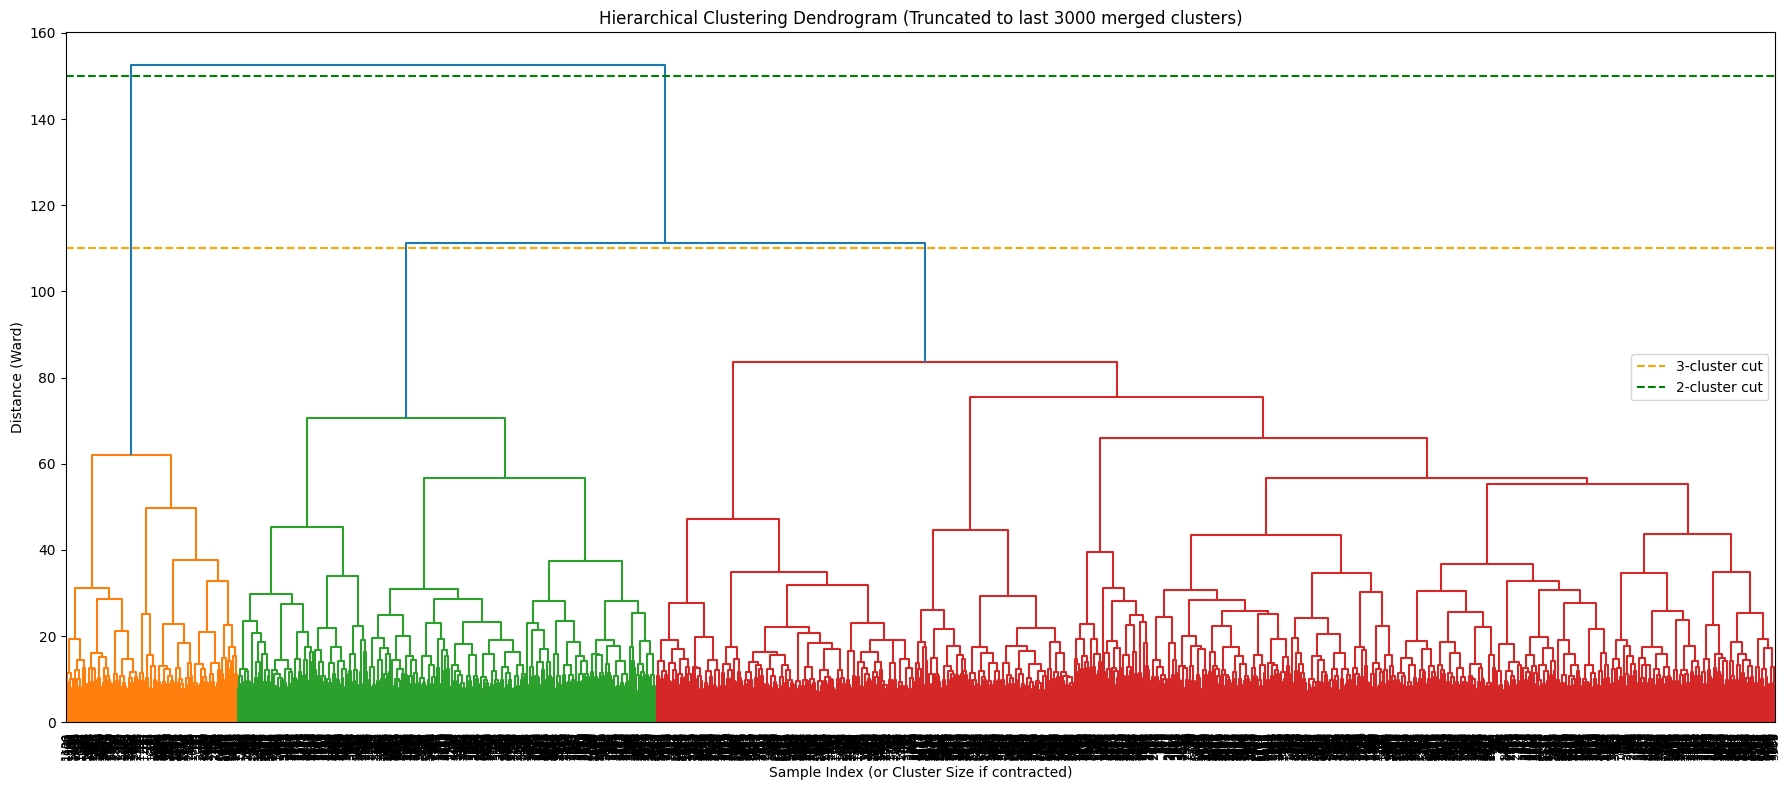

Dendrogram displayed.
Using 'filtered_sentence_lengths' for sentence lengths.

Cluster statistics (sentence length):
                    mean  min  max  median        std
cluster_label                                        
1              27.351598    9   53    26.0  10.097217
2              24.857605    4   52    24.0  10.679166
3              23.395683    6   53    22.0   9.672708
4              26.247453    7   53    26.0   9.037977
5              18.348276    1   53    16.0  10.627274
6              25.345455    5   50    24.0   9.066894
7              14.971751    2   50    12.0  10.959341
8              24.093168    4   53    23.0   9.715007

Mean Sentence Length Per Cluster:
cluster_label
1    27.351598
2    24.857605
3    23.395683
4    26.247453
5    18.348276
6    25.345455
7    14.971751
8    24.093168
Name: mean, dtype: float64

Number of Sentences Per Cluster:
cluster_label
1     219
2     309
3     278
4     687
5     580
6     330
7     177
8    1288
Name: count, dtype:

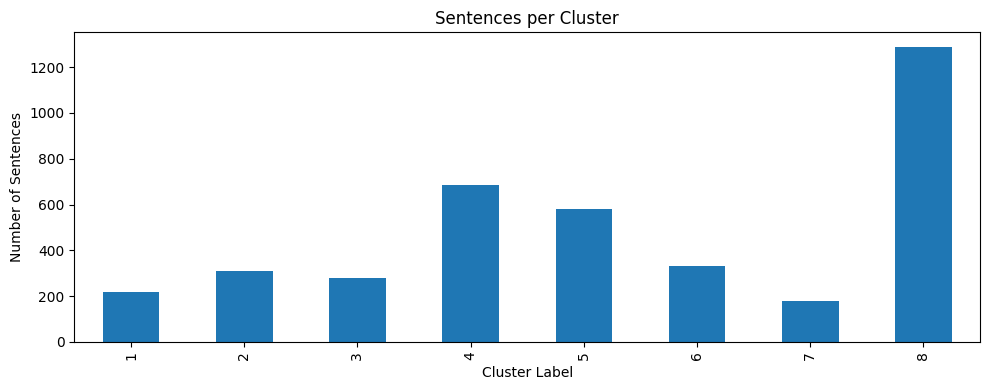

In [10]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import pandas as pd
import numpy as np

def plot_dendrogram(linked, p_clusters_to_show=3000, cut_lines=None):
    plt.figure(figsize=(18, 8))
    plt.title(f'Hierarchical Clustering Dendrogram (Truncated to last {p_clusters_to_show} merged clusters)')
    plt.xlabel('Sample Index (or Cluster Size if contracted)')
    plt.ylabel('Distance (Ward)')
    dendrogram(
        linked,
        truncate_mode='lastp',
        p=p_clusters_to_show,
        leaf_rotation=90.,
        leaf_font_size=8.,
        show_contracted=True,
    )
    if cut_lines:
        for y, color, label in cut_lines:
            plt.axhline(y=y, color=color, linestyle='--', label=label)
    plt.legend()
    plt.tight_layout()
    plt.show()

def get_sentence_lengths():
    # Prefer filtered_sentence_lengths if available, else y
    if 'filtered_sentence_lengths' in globals():
        print("Using 'filtered_sentence_lengths' for sentence lengths.")
        return filtered_sentence_lengths
    elif 'y' in globals():
        print("Using 'y' for sentence lengths.")
        return y
    else:
        print("Sentence lengths variable ('filtered_sentence_lengths' or 'y') not found.")
        print("Please ensure the cell that computes sentence lengths has been run.")
        return []

def analyze_clusters(linked, sentence_lengths, distance_threshold=60):
    cluster_labels = fcluster(linked, t=distance_threshold, criterion='distance')
    df_clusters = pd.DataFrame({
        'sentence_length': sentence_lengths,
        'cluster_label': cluster_labels
    })
    cluster_stats = df_clusters.groupby('cluster_label')['sentence_length'].agg(['mean', 'min', 'max', 'median', 'std'])
    print("\nCluster statistics (sentence length):")
    print(cluster_stats)
    print("\nMean Sentence Length Per Cluster:")
    print(cluster_stats['mean'])
    print("\nNumber of Sentences Per Cluster:")
    print(df_clusters['cluster_label'].value_counts().sort_index())
    # Optional: plot cluster sizes
    df_clusters['cluster_label'].value_counts().sort_index().plot(kind='bar', figsize=(10,4), title='Sentences per Cluster')
    plt.xlabel('Cluster Label')
    plt.ylabel('Number of Sentences')
    plt.tight_layout()
    plt.show()

print("Performing hierarchical clustering...")
linked = linkage(X_sentence_features, method='ward')
print("Clustering complete.")

plot_dendrogram(
    linked,
    p_clusters_to_show=3000,
    cut_lines=[(110, 'orange', "3-cluster cut"), (150, 'green', "2-cluster cut")]
)
print("Dendrogram displayed.")

sentence_lengths_for_clustering = get_sentence_lengths()
if sentence_lengths_for_clustering:
    analyze_clusters(linked, sentence_lengths_for_clustering, distance_threshold=60)
else:
    print("Could not compute mean length per cluster due to missing sentence lengths.")